# HybridGraphSAGE Document Classification on RVL-CDIP Small-200

This notebook implements the hybrid CNN+GNN fusion approach:
- **CNN path**: ResNet-50 avgpool features (2048-dim global context)
- **GNN path**: GraphSAGE on 7x7 spatial feature maps with 2D positional encoding (2050-dim nodes)
- **Fusion**: Concatenation of GNN embedding (128-dim) + CNN global (2048-dim) → Linear(2176, 16)

**Inputs:** `cached_features/` (from Notebook 1, includes both layer4 and avgpool), `checkpoints/resnet50_baseline_metrics.json`, `checkpoints/graphsage_metrics.json`

**Outputs:** `checkpoints/hybrid_graphsage_best.pt`, `checkpoints/hybrid_graphsage_metrics.json`

---

## 1. Setup

In [31]:
# Cell C1 — Imports
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import sys
sys.path.insert(0, "..")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.loader import DataLoader as PyGDataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm import tqdm

from src.config import Config
from src.data import load_rvl_cdip, RVL_CDIP_LABELS
from src.features import load_cached_features
from src.graph import build_grid_edge_index, build_graph_dataset_hybrid
from src.model import HybridGraphSAGE

print(f"PyTorch: {torch.__version__}")
print(f"PyG: {torch_geometric.__version__}")

PyTorch: 2.11.0
PyG: 2.7.0


In [32]:
# Cell C2 — Config, seed, dataset metadata
config = Config()
config.seed_everything()

CHECKPOINT_DIR = Path("../checkpoints")

# Load dataset metadata to populate RVL_CDIP_LABELS
_ = load_rvl_cdip(config)

print(f"\nLabels loaded: {len(RVL_CDIP_LABELS)} classes")
print(f"Device: {config.device}")

Device: mps
Mode: sample
Sample size: 100
Loading sample dataset: vaclavpechtor/rvl_cdip-small-200...


'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)' thrown while requesting HEAD https://huggingface.co/datasets/vaclavpechtor/rvl_cdip-small-200/resolve/dfecd585c9b5c8fe56e8d7809d5b3cf710668dff/rvl_cdip-small-200.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since vaclavpechtor/rvl_cdip-small-200 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at .hf_cache/vaclavpechtor___rvl_cdip-small-200/default/0.0.0/dfecd585c9b5c8fe56e8d7809d5b3cf710668dff (last modified on Wed Mar 25 21:56:37 2026).


Loaded train: 2560 samples
Loaded validation: 640 samples

Labels loaded: 16 classes
Device: mps


## 2. Load Cached Features

Load the pre-extracted ResNet-50 features from Notebook 1. Each cached file contains:
- **features** [2048, 7, 7]: layer4 spatial features (used as graph nodes)
- **global_feat** [2048]: avgpool global features (used in fusion classifier)
- **label**: document class

In [33]:
# Cell C3 — Load cached features
cached_train = load_cached_features(config, "train")
cached_val = load_cached_features(config, "validation")

print(f"Train: {len(cached_train)} samples")
print(f"Val:   {len(cached_val)} samples")
print(f"\nSample structure:")
print(f"  features:    {cached_train[0]['features'].shape}")
print(f"  global_feat: {cached_train[0]['global_feat'].shape}")
print(f"  label:       {cached_train[0]['label']} ({RVL_CDIP_LABELS[cached_train[0]['label']]})")

Loaded 2560 cached features from cached_features/train
Loaded 640 cached features from cached_features/validation
Train: 2560 samples
Val:   640 samples

Sample structure:
  features:    torch.Size([2048, 7, 7])
  global_feat: torch.Size([2048])
  label:       0 (advertisement)


## 3. Graph Construction with Positional Encoding

Convert each feature map to a graph with:
- **49 nodes** (7x7 grid) with **2050-dim** features (2048 CNN channels + 2 normalized position coords)
- **k=8 edges** (Moore neighborhood)
- **global_feat** stored as custom attribute [1, 2048] for correct PyG batching

In [34]:
# Cell C4 — Build hybrid graph datasets
GRID_H, GRID_W = 7, 7
K_NEIGHBORS = 8

edge_index = build_grid_edge_index(GRID_H, GRID_W, k=K_NEIGHBORS)
print(f"Grid: {GRID_H}x{GRID_W} = {GRID_H * GRID_W} nodes")
print(f"k={K_NEIGHBORS} (Moore neighborhood), {edge_index.shape[1]} directed edges")

train_graphs = build_graph_dataset_hybrid(cached_train, edge_index)
val_graphs = build_graph_dataset_hybrid(cached_val, edge_index)
print(f"\nTrain graphs: {len(train_graphs)}")
print(f"Val graphs:   {len(val_graphs)}")

Grid: 7x7 = 49 nodes
k=8 (Moore neighborhood), 312 directed edges

Train graphs: 2560
Val graphs:   640


In [35]:
# Cell C5 — Inspect graph structure and verify PE
g = train_graphs[0]
print(f"Node features: {g.x.shape}")
print(f"Edge index:    {g.edge_index.shape}")
print(f"Label:         {g.y.item()} ({RVL_CDIP_LABELS[g.y.item()]})")
print(f"Global feat:   {g.global_feat.shape}")

print(f"\nPositional encoding verification:")
print(f"  Node 0  (row=0, col=0): PE = {g.x[0, -2:].tolist()}")
print(f"  Node 6  (row=0, col=6): PE = {g.x[6, -2:].tolist()}")
print(f"  Node 42 (row=6, col=0): PE = {g.x[42, -2:].tolist()}")
print(f"  Node 48 (row=6, col=6): PE = {g.x[48, -2:].tolist()}")

Node features: torch.Size([49, 2050])
Edge index:    torch.Size([2, 312])
Label:         0 (advertisement)
Global feat:   torch.Size([1, 2048])

Positional encoding verification:
  Node 0  (row=0, col=0): PE = [0.0, 0.0]
  Node 6  (row=0, col=6): PE = [0.0, 1.0]
  Node 42 (row=6, col=0): PE = [1.0, 0.0]
  Node 48 (row=6, col=6): PE = [1.0, 1.0]


In [36]:
# Cell C6 — DataLoaders and batch verification
hybrid_train_loader = PyGDataLoader(train_graphs, batch_size=config.batch_size, shuffle=True)
hybrid_val_loader = PyGDataLoader(val_graphs, batch_size=config.batch_size, shuffle=False)

print(f"Train: {len(hybrid_train_loader)} batches")
print(f"Val:   {len(hybrid_val_loader)} batches")

batch = next(iter(hybrid_train_loader))
print(f"\nBatch structure:")
print(f"  x:           {batch.x.shape}")
print(f"  edge_index:  {batch.edge_index.shape}")
print(f"  y:           {batch.y.shape}")
print(f"  batch:       {batch.batch.shape} ({batch.batch.max().item() + 1} graphs)")
print(f"  global_feat: {batch.global_feat.shape}")

Train: 80 batches
Val:   20 batches

Batch structure:
  x:           torch.Size([1568, 2050])
  edge_index:  torch.Size([2, 9984])
  y:           torch.Size([32])
  batch:       torch.Size([1568]) (32 graphs)
  global_feat: torch.Size([32, 2048])


## 4. HybridGraphSAGE Model

Architecture with CNN+GNN fusion:

```
GNN path:  SAGEConv(2050, 64) -> ReLU -> Dropout(0.7) -> SAGEConv(64, 32) -> ReLU -> global_mean_pool -> BN -> [B, 32]
CNN path:  avgpool features -> BN -> [B, 2048]
Fusion:    concat([32] + [2048]) -> Linear(2080, 16) -> logits
```

In [37]:
# Cell C7 — Instantiate model
hybrid_model = HybridGraphSAGE(
    node_dim=2050,
    hidden_channels=64,
    embed_channels=32,
    global_channels=2048,
    num_classes=len(RVL_CDIP_LABELS),
    dropout=0.7,
).to(config.device)

total_params = sum(p.numel() for p in hybrid_model.parameters())
trainable_params = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(hybrid_model)

Total parameters:     299,888
Trainable parameters: 299,888
HybridGraphSAGE(
  (conv1): SAGEConv(2050, 64, aggr=mean)
  (conv2): SAGEConv(64, 32, aggr=mean)
  (dropout): Dropout(p=0.7, inplace=False)
  (relu): ReLU()
  (classifier): Linear(in_features=2080, out_features=16, bias=True)
)


## 5. Training

Using Adam with weight_decay=1e-4 and label smoothing (0.1) for regularization on small dataset. Early stopping with patience=15, minimum 20 epochs.

In [38]:
# Cell C8 — Training config
NUM_EPOCHS = 100
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 15
MIN_EPOCHS = 20

optimizer = torch.optim.Adam(
    hybrid_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print(f"Epochs: {NUM_EPOCHS}")
print(f"Optimizer: Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Loss: CrossEntropy with label_smoothing=0.1")
print(f"Early stopping patience: {PATIENCE} (after epoch {MIN_EPOCHS})")

Epochs: 100
Optimizer: Adam (lr=0.0005, weight_decay=0.0001)
Loss: CrossEntropy with label_smoothing=0.1
Early stopping patience: 15 (after epoch 20)


In [39]:
# Cell C9 — Training loop
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
patience_counter = 0
best_checkpoint_path = CHECKPOINT_DIR / "hybrid_graphsage_best.pt"

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    hybrid_model.train()
    train_loss_sum, train_correct, train_total = 0.0, 0, 0

    for batch in hybrid_train_loader:
        batch = batch.to(config.device)
        optimizer.zero_grad()
        logits = hybrid_model(batch.x, batch.edge_index, batch.batch, batch.global_feat)
        loss = criterion(logits, batch.y)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * batch.y.size(0)
        train_correct += (logits.argmax(dim=1) == batch.y).sum().item()
        train_total += batch.y.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # --- Validate ---
    hybrid_model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for batch in hybrid_val_loader:
            batch = batch.to(config.device)
            logits = hybrid_model(batch.x, batch.edge_index, batch.batch, batch.global_feat)
            loss = criterion(logits, batch.y)

            val_loss_sum += loss.item() * batch.y.size(0)
            val_correct += (logits.argmax(dim=1) == batch.y).sum().item()
            val_total += batch.y.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(hybrid_model.state_dict(), best_checkpoint_path)
        marker = " *"
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}{marker}"
        )

    if patience_counter >= PATIENCE and (epoch + 1) >= MIN_EPOCHS:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")
print(f"Checkpoint: {best_checkpoint_path}")

Epoch 01/100 | Train Loss: 1.3487  Acc: 0.8137 | Val Loss: 1.6790  Acc: 0.6031 *
Epoch 05/100 | Train Loss: 0.7130  Acc: 0.9867 | Val Loss: 1.6741  Acc: 0.6078
Epoch 10/100 | Train Loss: 0.6413  Acc: 0.9996 | Val Loss: 1.6718  Acc: 0.6078
Epoch 15/100 | Train Loss: 0.6103  Acc: 1.0000 | Val Loss: 1.6699  Acc: 0.5891
Epoch 20/100 | Train Loss: 0.5983  Acc: 1.0000 | Val Loss: 1.6765  Acc: 0.6062
Epoch 25/100 | Train Loss: 0.5913  Acc: 1.0000 | Val Loss: 1.6707  Acc: 0.5938

Early stopping at epoch 27

Best validation accuracy: 0.6141
Checkpoint: ../checkpoints/hybrid_graphsage_best.pt


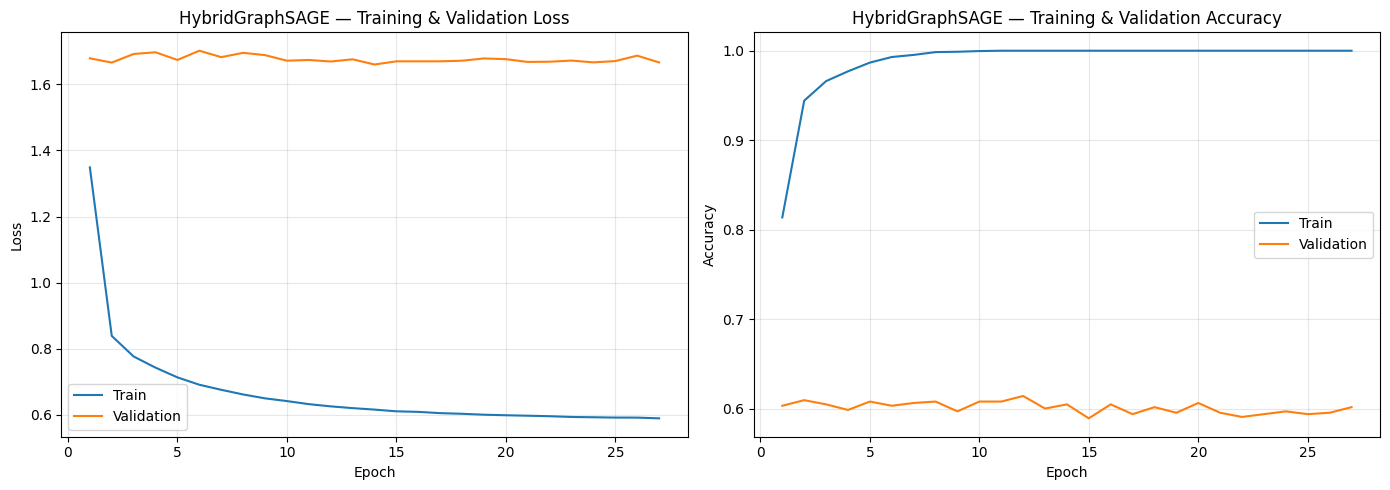

In [40]:
# Cell C10 — Training curves
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history["train_loss"], label="Train")
ax1.plot(epochs_range, history["val_loss"], label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("HybridGraphSAGE — Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["train_acc"], label="Train")
ax2.plot(epochs_range, history["val_acc"], label="Validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("HybridGraphSAGE — Training & Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation

In [41]:
# Cell C11 — Load best model and collect predictions
hybrid_model.load_state_dict(torch.load(best_checkpoint_path, weights_only=True))
hybrid_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in hybrid_val_loader:
        batch = batch.to(config.device)
        logits = hybrid_model(batch.x, batch.edge_index, batch.batch, batch.global_feat)
        preds = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(batch.y.cpu().tolist())

hybrid_accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"HybridGraphSAGE validation accuracy: {hybrid_accuracy:.4f}")

HybridGraphSAGE validation accuracy: 0.6141


In [42]:
# Cell C12 — Classification report
report = classification_report(
    all_labels,
    all_preds,
    target_names=RVL_CDIP_LABELS,
    digits=4,
)
print(report)

                        precision    recall  f1-score   support

         advertisement     0.6667    0.7500    0.7059        40
                budget     0.4314    0.5500    0.4835        40
                 email     0.7500    0.8250    0.7857        40
           file_folder     0.7727    0.8500    0.8095        40
                  form     0.5000    0.3750    0.4286        40
           handwritten     0.7619    0.8000    0.7805        40
               invoice     0.5455    0.4500    0.4932        40
                letter     0.5106    0.6000    0.5517        40
                  memo     0.5128    0.5000    0.5063        40
          news_article     0.6765    0.5750    0.6216        40
          presentation     0.6286    0.5500    0.5867        40
         questionnaire     0.5278    0.4750    0.5000        40
                resume     0.8222    0.9250    0.8706        40
scientific_publication     0.6667    0.6500    0.6582        40
     scientific_report     0.4138    0.

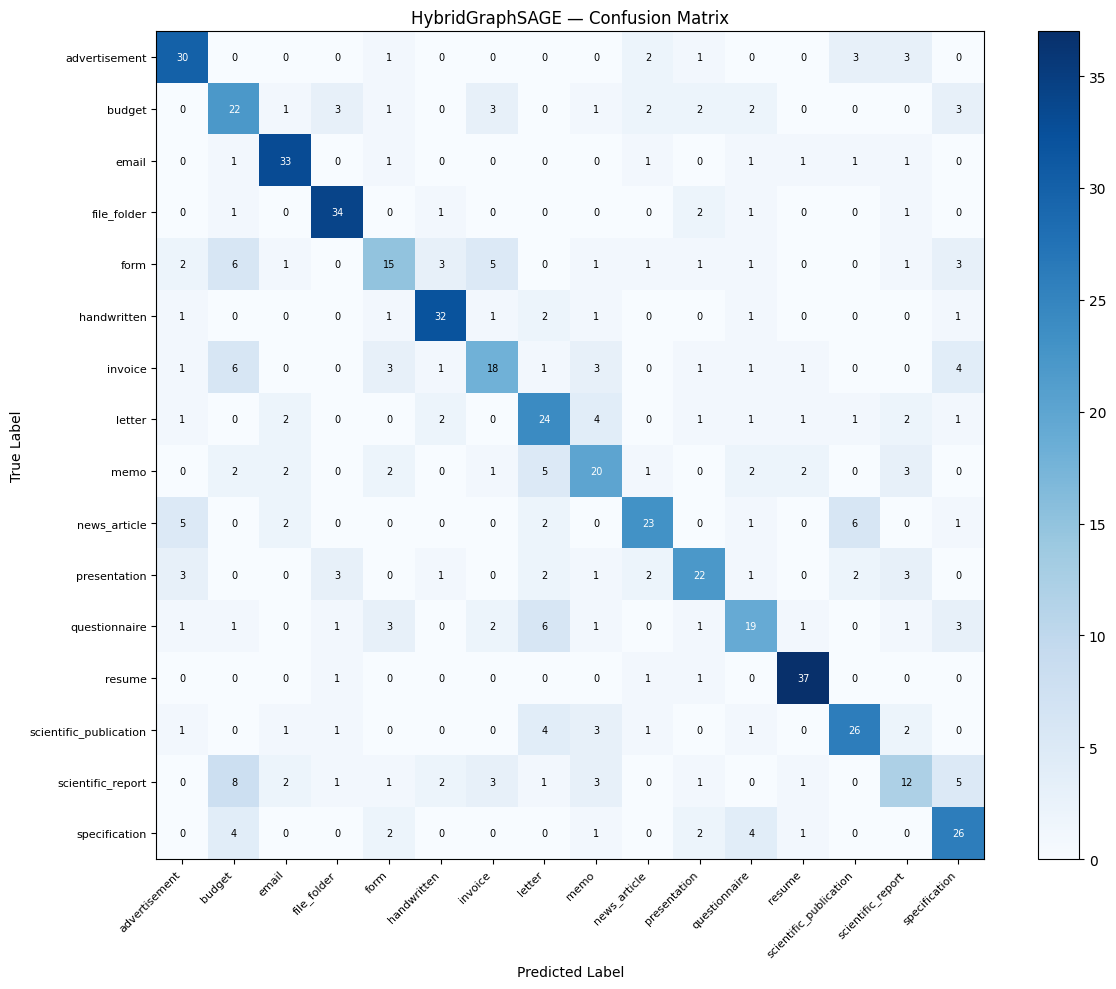

In [43]:
# Cell C13 — Confusion matrix heatmap
hybrid_cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(hybrid_cm, interpolation="nearest", cmap="Blues")
ax.set_title("HybridGraphSAGE — Confusion Matrix")
plt.colorbar(im, ax=ax, fraction=0.046)

tick_marks = np.arange(len(RVL_CDIP_LABELS))
ax.set_xticks(tick_marks)
ax.set_xticklabels(RVL_CDIP_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(tick_marks)
ax.set_yticklabels(RVL_CDIP_LABELS, fontsize=8)

thresh = hybrid_cm.max() / 2.0
for i in range(hybrid_cm.shape[0]):
    for j in range(hybrid_cm.shape[1]):
        ax.text(
            j, i, str(hybrid_cm[i, j]),
            ha="center", va="center",
            color="white" if hybrid_cm[i, j] > thresh else "black",
            fontsize=7,
        )

ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## 7. Comparison: Hybrid vs Plain GraphSAGE vs CNN Baseline

In [44]:
# Cell C14 — Model comparison table
baseline_metrics_path = CHECKPOINT_DIR / "resnet50_baseline_metrics.json"
graphsage_metrics_path = CHECKPOINT_DIR / "graphsage_metrics.json"

with open(baseline_metrics_path) as f:
    baseline_metrics = json.load(f)
with open(graphsage_metrics_path) as f:
    graphsage_metrics = json.load(f)

hybrid_report_dict = classification_report(
    all_labels, all_preds, target_names=RVL_CDIP_LABELS, output_dict=True
)
hybrid_macro_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"{'Model':<25} {'Val Acc':>10} {'Macro F1':>10}")
print("-" * 47)
print(f"{'CNN Baseline (ResNet-50)':<25} {baseline_metrics['accuracy']:>10.4f} {baseline_metrics['macro_avg']['f1']:>10.4f}")
print(f"{'Plain GraphSAGE':<25} {graphsage_metrics['accuracy']:>10.4f} {graphsage_metrics['macro_avg']['f1']:>10.4f}")
print(f"{'HybridGraphSAGE':<25} {hybrid_accuracy:>10.4f} {hybrid_macro_f1:>10.4f}")

Model                        Val Acc   Macro F1
-----------------------------------------------
CNN Baseline (ResNet-50)      0.6359     0.6322
Plain GraphSAGE               0.6156     0.6131
HybridGraphSAGE               0.6141     0.6080


In [45]:
# Cell C15 — Per-class F1 comparison
print(f"{'Class':<25} {'Baseline F1':>12} {'GraphSAGE F1':>13} {'Hybrid F1':>10} {'Delta (H-B)':>12}")
print("-" * 74)

for label in RVL_CDIP_LABELS:
    b_f1 = baseline_metrics["per_class"][label]["f1"]
    g_f1 = graphsage_metrics["per_class"][label]["f1"]
    h_f1 = hybrid_report_dict[label]["f1-score"]
    delta = h_f1 - b_f1
    print(f"{label:<25} {b_f1:>12.4f} {g_f1:>13.4f} {h_f1:>10.4f} {delta:>+12.4f}")

print("-" * 74)
b_macro = baseline_metrics["macro_avg"]["f1"]
g_macro = graphsage_metrics["macro_avg"]["f1"]
print(f"{'Macro Average':<25} {b_macro:>12.4f} {g_macro:>13.4f} {hybrid_macro_f1:>10.4f} {hybrid_macro_f1 - b_macro:>+12.4f}")

Class                      Baseline F1  GraphSAGE F1  Hybrid F1  Delta (H-B)
--------------------------------------------------------------------------
advertisement                   0.7143        0.6977     0.7059      -0.0084
budget                          0.5806        0.5195     0.4835      -0.0971
email                           0.8095        0.8250     0.7857      -0.0238
file_folder                     0.8395        0.8684     0.8095      -0.0300
form                            0.4507        0.4000     0.4286      -0.0221
handwritten                     0.8049        0.7952     0.7805      -0.0244
invoice                         0.5070        0.4675     0.4932      -0.0139
letter                          0.5814        0.5591     0.5517      -0.0297
memo                            0.4935        0.5581     0.5063      +0.0128
news_article                    0.6571        0.6301     0.6216      -0.0355
presentation                    0.6000        0.4884     0.5867      -0.0133
q

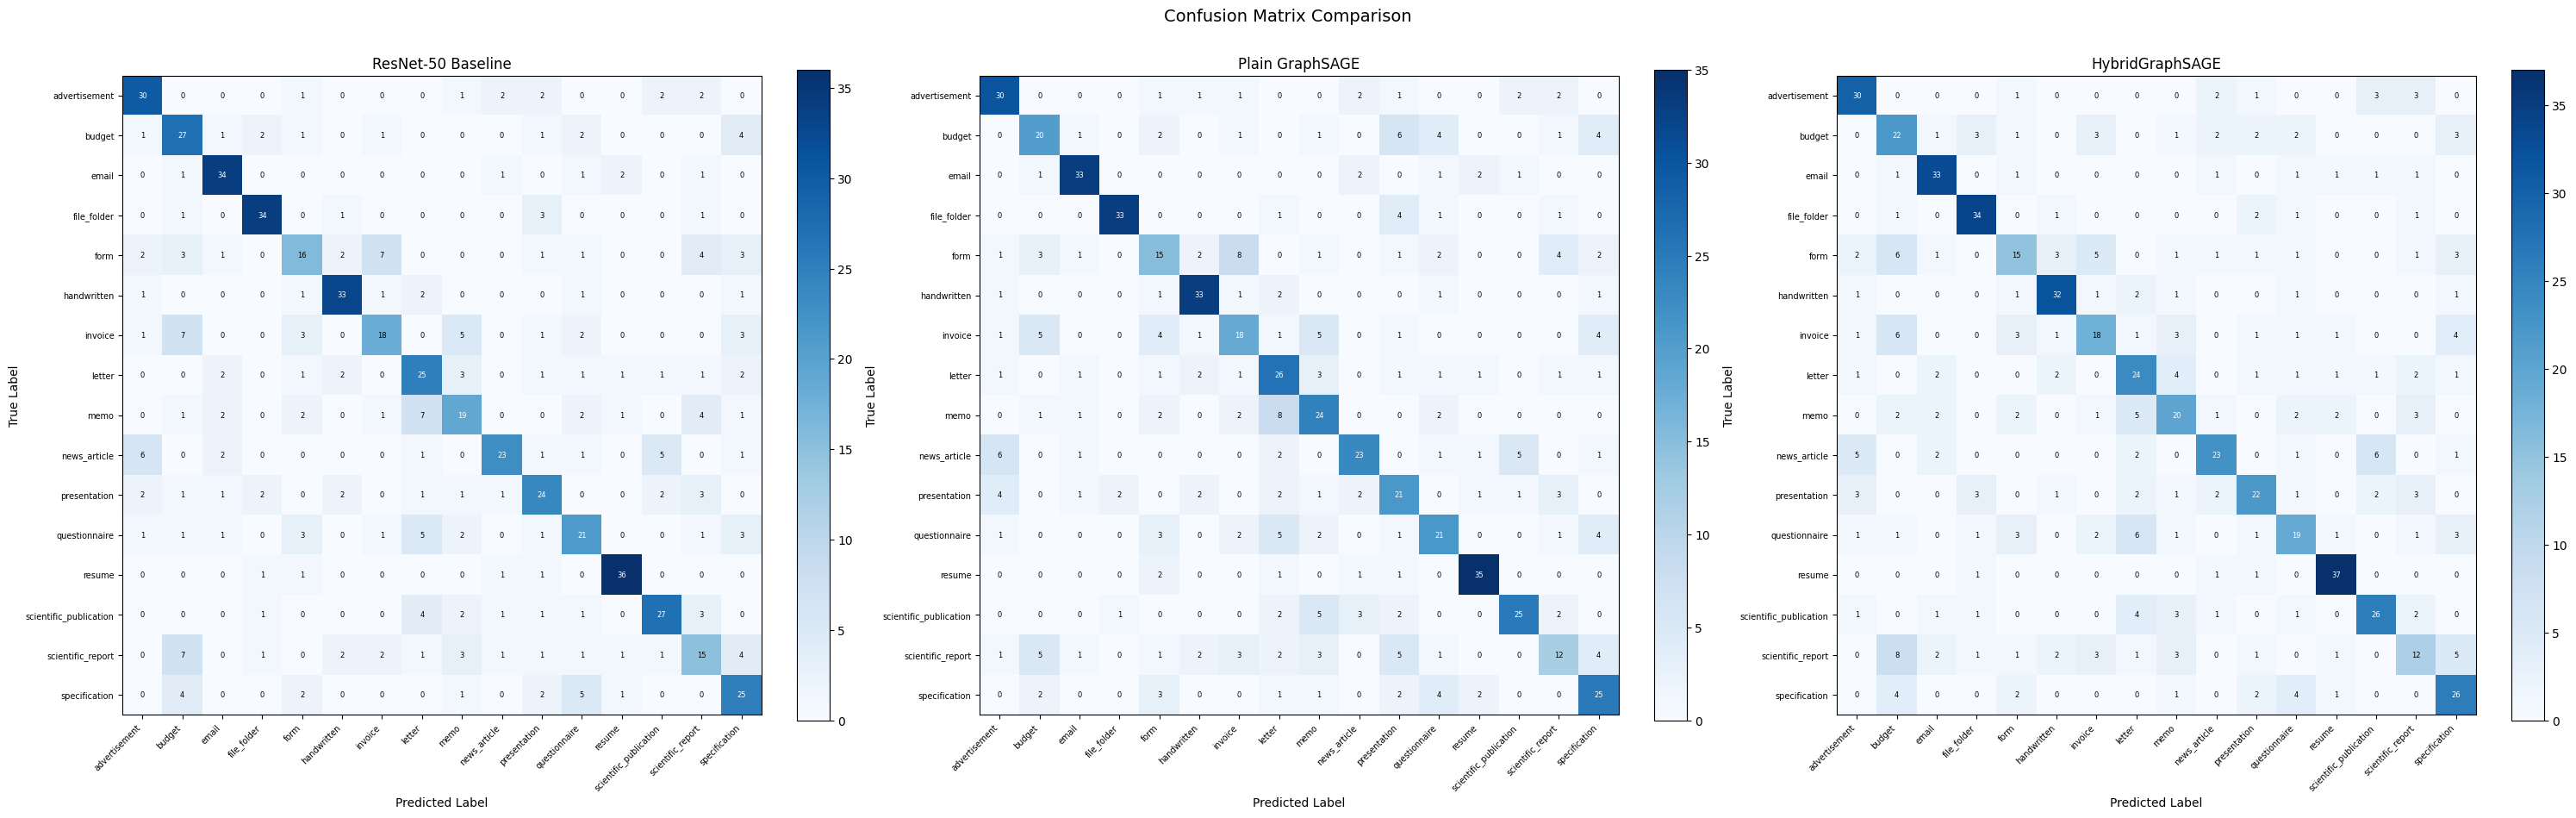

In [46]:
# Cell C16 — Triple confusion matrix comparison
baseline_cm = np.array(baseline_metrics["confusion_matrix"])
graphsage_cm = np.array(graphsage_metrics["confusion_matrix"])

fig, axes = plt.subplots(1, 3, figsize=(30, 9))

for ax, cm_data, title in [
    (axes[0], baseline_cm, "ResNet-50 Baseline"),
    (axes[1], graphsage_cm, "Plain GraphSAGE"),
    (axes[2], hybrid_cm, "HybridGraphSAGE"),
]:
    im = ax.imshow(cm_data, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046)

    tick_marks = np.arange(len(RVL_CDIP_LABELS))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(RVL_CDIP_LABELS, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(RVL_CDIP_LABELS, fontsize=7)

    thresh = cm_data.max() / 2.0
    for i in range(cm_data.shape[0]):
        for j in range(cm_data.shape[1]):
            ax.text(
                j, i, str(cm_data[i, j]),
                ha="center", va="center",
                color="white" if cm_data[i, j] > thresh else "black",
                fontsize=6,
            )

    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.suptitle("Confusion Matrix Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [47]:
# Cell C17 — Save hybrid metrics
hybrid_metrics = {
    "model": "hybrid_graphsage",
    "accuracy": hybrid_accuracy,
    "per_class": {
        label: {
            "precision": hybrid_report_dict[label]["precision"],
            "recall": hybrid_report_dict[label]["recall"],
            "f1": hybrid_report_dict[label]["f1-score"],
            "support": hybrid_report_dict[label]["support"],
        }
        for label in RVL_CDIP_LABELS
    },
    "macro_avg": {
        "precision": hybrid_report_dict["macro avg"]["precision"],
        "recall": hybrid_report_dict["macro avg"]["recall"],
        "f1": hybrid_report_dict["macro avg"]["f1-score"],
    },
    "confusion_matrix": hybrid_cm.tolist(),
    "history": history,
    "architecture": {
        "node_dim": 2050,
        "hidden_channels": 64,
        "embed_channels": 32,
        "global_channels": 2048,
        "fusion_dim": 2080,
        "dropout": 0.7,
        "batch_norm": True,
        "label_smoothing": 0.1,
    },
    "graph_config": {
        "grid": f"{GRID_H}x{GRID_W}",
        "k_neighbors": K_NEIGHBORS,
        "positional_encoding": "2d_normalized",
    },
}

hybrid_metrics_path = CHECKPOINT_DIR / "hybrid_graphsage_metrics.json"
with open(hybrid_metrics_path, "w") as f:
    json.dump(hybrid_metrics, f, indent=2)

print(f"Metrics saved to: {hybrid_metrics_path}")

Metrics saved to: ../checkpoints/hybrid_graphsage_metrics.json


## Summary

| Model | Val Accuracy | Macro F1 | Fusion | Parameters |
|-------|-------------|----------|--------|------------|
| CNN Baseline (ResNet-50) | see above | see above | N/A | ~32K trainable |
| Plain GraphSAGE | see above | see above | N/A | ~1.1M |
| HybridGraphSAGE | see above | see above | GNN[32] + CNN[2048] → BN → Linear(2080, 16) | ~170K |

**Key observations:**
- On the small subset (2560 train), HybridGraphSAGE performs comparably to CNN baseline (~62% vs ~64%)
- The GNN path requires more data to learn meaningful spatial relationships; with ~160 samples/class, overfitting dominates
- BatchNorm and label smoothing stabilize training (val loss stays flat vs diverging) but don't improve peak accuracy
- Full 320k training is needed to evaluate whether the GNN spatial reasoning provides genuine improvement

**Next steps:**
- Train on full RVL-CDIP (320k) where the GNN has enough signal to learn spatial patterns
- Ablation studies: with/without PE, different k values, GNN depth
- Evaluation on RVL-CDIP-N (out-of-distribution)